# 🚗 Détection de Plaques d'Immatriculation avec YOLOv8
### Auteur : Mickael MOISAN (ACT-IA) | Créé avec l'assistance de Claude Opus 4.5 (Anthropic) | Le 05/02/2026


Ce notebook permet d'entraîner un modèle YOLOv8n sur le dataset UC3M-LP pour :
1. **Détection de plaques (LP)** - Localiser les plaques sur une image
2. **Reconnaissance de caractères (OCR)** - Lire les caractères sur la plaque

---

## 1. Installation et Configuration

In [ ]:
# Installation d'Ultralytics (YOLOv8)
# !pip install ultralytics -q

In [3]:
# Imports
import os
from ultralytics import YOLO
from IPython.display import Image, display, clear_output
import yaml

print("✅ Imports réussis !")

✅ Imports réussis !


In [4]:
# Définir le répertoire de travail
# ⚠️ MODIFIER CE CHEMIN selon votre configuration
WORK_DIR = "/mnt/c/DEV/jedha/fullstack_wsl/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/YOLO8-n/ROBOFLOW_universe"
os.chdir(WORK_DIR)
print(f"📁 Répertoire de travail : {os.getcwd()}")

📁 Répertoire de travail : /mnt/c/DEV/jedha/fullstack_wsl/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/YOLO8-n/ROBOFLOW_universe


## 2. Configuration des fichiers YAML

Les fichiers YAML définissent où se trouvent les données d'entraînement.

In [5]:
# Vérifier la structure du dataset
!ls -la path/to/ROBOFLOW_universe-yolo/

ls: cannot access 'path/to/ROBOFLOW_universe-yolo/': No such file or directory


In [23]:
# Créer/Modifier le fichier YAML pour la détection de plaques (LP)
lp_config = {
    'path': os.path.join(WORK_DIR, '.-yolo/LP'),
    'train': 'images/train',
    'val': 'images/val',
    'names': {
        0: 'license_plate'
    }
}

with open('cfg/UC3M-LP-lp.yaml', 'w') as f:
    yaml.dump(lp_config, f, default_flow_style=False)

print("✅ Fichier cfg/UC3M-LP-lp.yaml créé !")
print("\nContenu :")
!cat cfg/UC3M-LP-lp.yaml

✅ Fichier cfg/UC3M-LP-lp.yaml créé !

Contenu :
names:
  0: license_plate
path: /mnt/c/DEV/jedha/fullstack_wsl/PROJETS/PROJET_FINAL/YOLO8-n/UC3M-LP/.-yolo/LP
train: images/train
val: images/val


In [24]:
# Créer/Modifier le fichier YAML pour l'OCR
ocr_config = {
    'path': os.path.join(WORK_DIR, '.-yolo/OCR'),
    'train': 'images/train',
    'val': 'images/val',
    'names': {i: c for i, c in enumerate('0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ')}
}

with open('cfg/UC3M-LP-ocr.yaml', 'w') as f:
    yaml.dump(ocr_config, f, default_flow_style=False)

print("✅ Fichier cfg/UC3M-LP-ocr.yaml créé !")

✅ Fichier cfg/UC3M-LP-ocr.yaml créé !


## 3. Entraînement - Détection de Plaques (LP)

In [25]:
# Charger le modèle YOLOv8 nano pré-entraîné
model_lp = YOLO('yolov8n.pt')
print("✅ Modèle YOLOv8n chargé !")

✅ Modèle YOLOv8n chargé !


In [26]:
# Exécute cette cellule pour voir la vraie structure
!ls -la
!echo "---"
!find . -name "images" -type d 2>/dev/null

total 11888
drwxrwxrwx 1 mmo mmo    4096 Feb  5 16:21 .
drwxrwxrwx 1 mmo mmo    4096 Feb  5 15:34 .-yolo
drwxrwxrwx 1 mmo mmo    4096 Feb  5 15:24 ..
drwxrwxrwx 1 mmo mmo    4096 Feb  5 15:45 .git
drwxrwxrwx 1 mmo mmo    4096 Feb  5 15:24 .github
-rwxrwxrwx 1 mmo mmo    1838 Feb  5 15:24 .gitignore
-rwxrwxrwx 1 mmo mmo   25217 Feb  5 15:24 LICENSE
-rwxrwxrwx 1 mmo mmo    4433 Feb  5 15:24 README.md
-rwxrwxrwx 1 mmo mmo   14592 Feb  5 16:17 YOLOv8_UC3M_LP_Training.ipynb
drwxrwxrwx 1 mmo mmo    4096 Feb  5 16:11 cfg
drwxrwxrwx 1 mmo mmo    4096 Feb  5 15:24 docs
drwxrwxrwx 1 mmo mmo    4096 Feb  5 15:35 path
-rwxrwxrwx 1 mmo mmo      21 Feb  5 15:24 requirements.txt
drwxrwxrwx 1 mmo mmo    4096 Feb  5 16:27 runs
drwxrwxrwx 1 mmo mmo    4096 Feb  5 15:24 sample
drwxrwxrwx 1 mmo mmo    4096 Feb  5 15:43 scripts
drwxrwxrwx 1 mmo mmo    4096 Feb  5 15:42 test
-rwxrwxrwx 1 mmo mmo    2370 Feb  5 15:41 test.txt
drwxrwxrwx 1 mmo mmo    4096 Feb  5 15:42 train
-rwxrwxrwx 1 mmo mmo    9480 Feb  5

In [27]:
# Entraînement du modèle de détection de plaques
# ⚠️ Ajustez les paramètres selon vos ressources GPU/CPU

results_lp = model_lp.train(
    data='cfg/UC3M-LP-lp.yaml',
    epochs=100,              # Nombre d'époques
    imgsz=320,               # Taille des images
    batch=16,                # Taille du batch (réduire si manque de mémoire)
    name='LP_detection',     # Nom de l'expérience
    patience=20,             # Early stopping après 20 époques sans amélioration
    save=True,               # Sauvegarder les checkpoints
    plots=True               # Générer les graphiques
)

Ultralytics 8.4.12 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cfg/UC3M-LP-lp.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=LP_detection3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

In [28]:
# Afficher les métriques d'entraînement LP
print("📊 Résultats de l'entraînement LP :")
print(f"   - mAP50: {results_lp.results_dict.get('metrics/mAP50(B)', 'N/A')}")
print(f"   - mAP50-95: {results_lp.results_dict.get('metrics/mAP50-95(B)', 'N/A')}")

📊 Résultats de l'entraînement LP :
   - mAP50: 0.965750560970874
   - mAP50-95: 0.760638441444289


In [29]:
# Visualiser les courbes d'entraînement
from IPython.display import Image, display

# Afficher les courbes de loss et métriques
results_path = 'runs/detect/LP_detection/'
if os.path.exists(results_path + 'results.png'):
    display(Image(filename=results_path + 'results.png', width=800))

## 4. Entraînement - OCR (Reconnaissance de Caractères)

In [30]:
# Charger un nouveau modèle pour l'OCR
model_ocr = YOLO('yolov8n.pt')
print("✅ Modèle YOLOv8n chargé pour OCR !")

✅ Modèle YOLOv8n chargé pour OCR !


In [31]:
# Entraînement du modèle OCR
results_ocr = model_ocr.train(
    data='cfg/UC3M-LP-ocr.yaml',
    epochs=100,
    imgsz=160,               # Plus petit car on travaille sur les plaques croppées
    batch=32,                # Batch plus grand car images plus petites
    name='OCR_detection',
    patience=20,
    save=True,
    plots=True
)

Ultralytics 8.4.12 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cfg/UC3M-LP-ocr.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=160, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=OCR_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

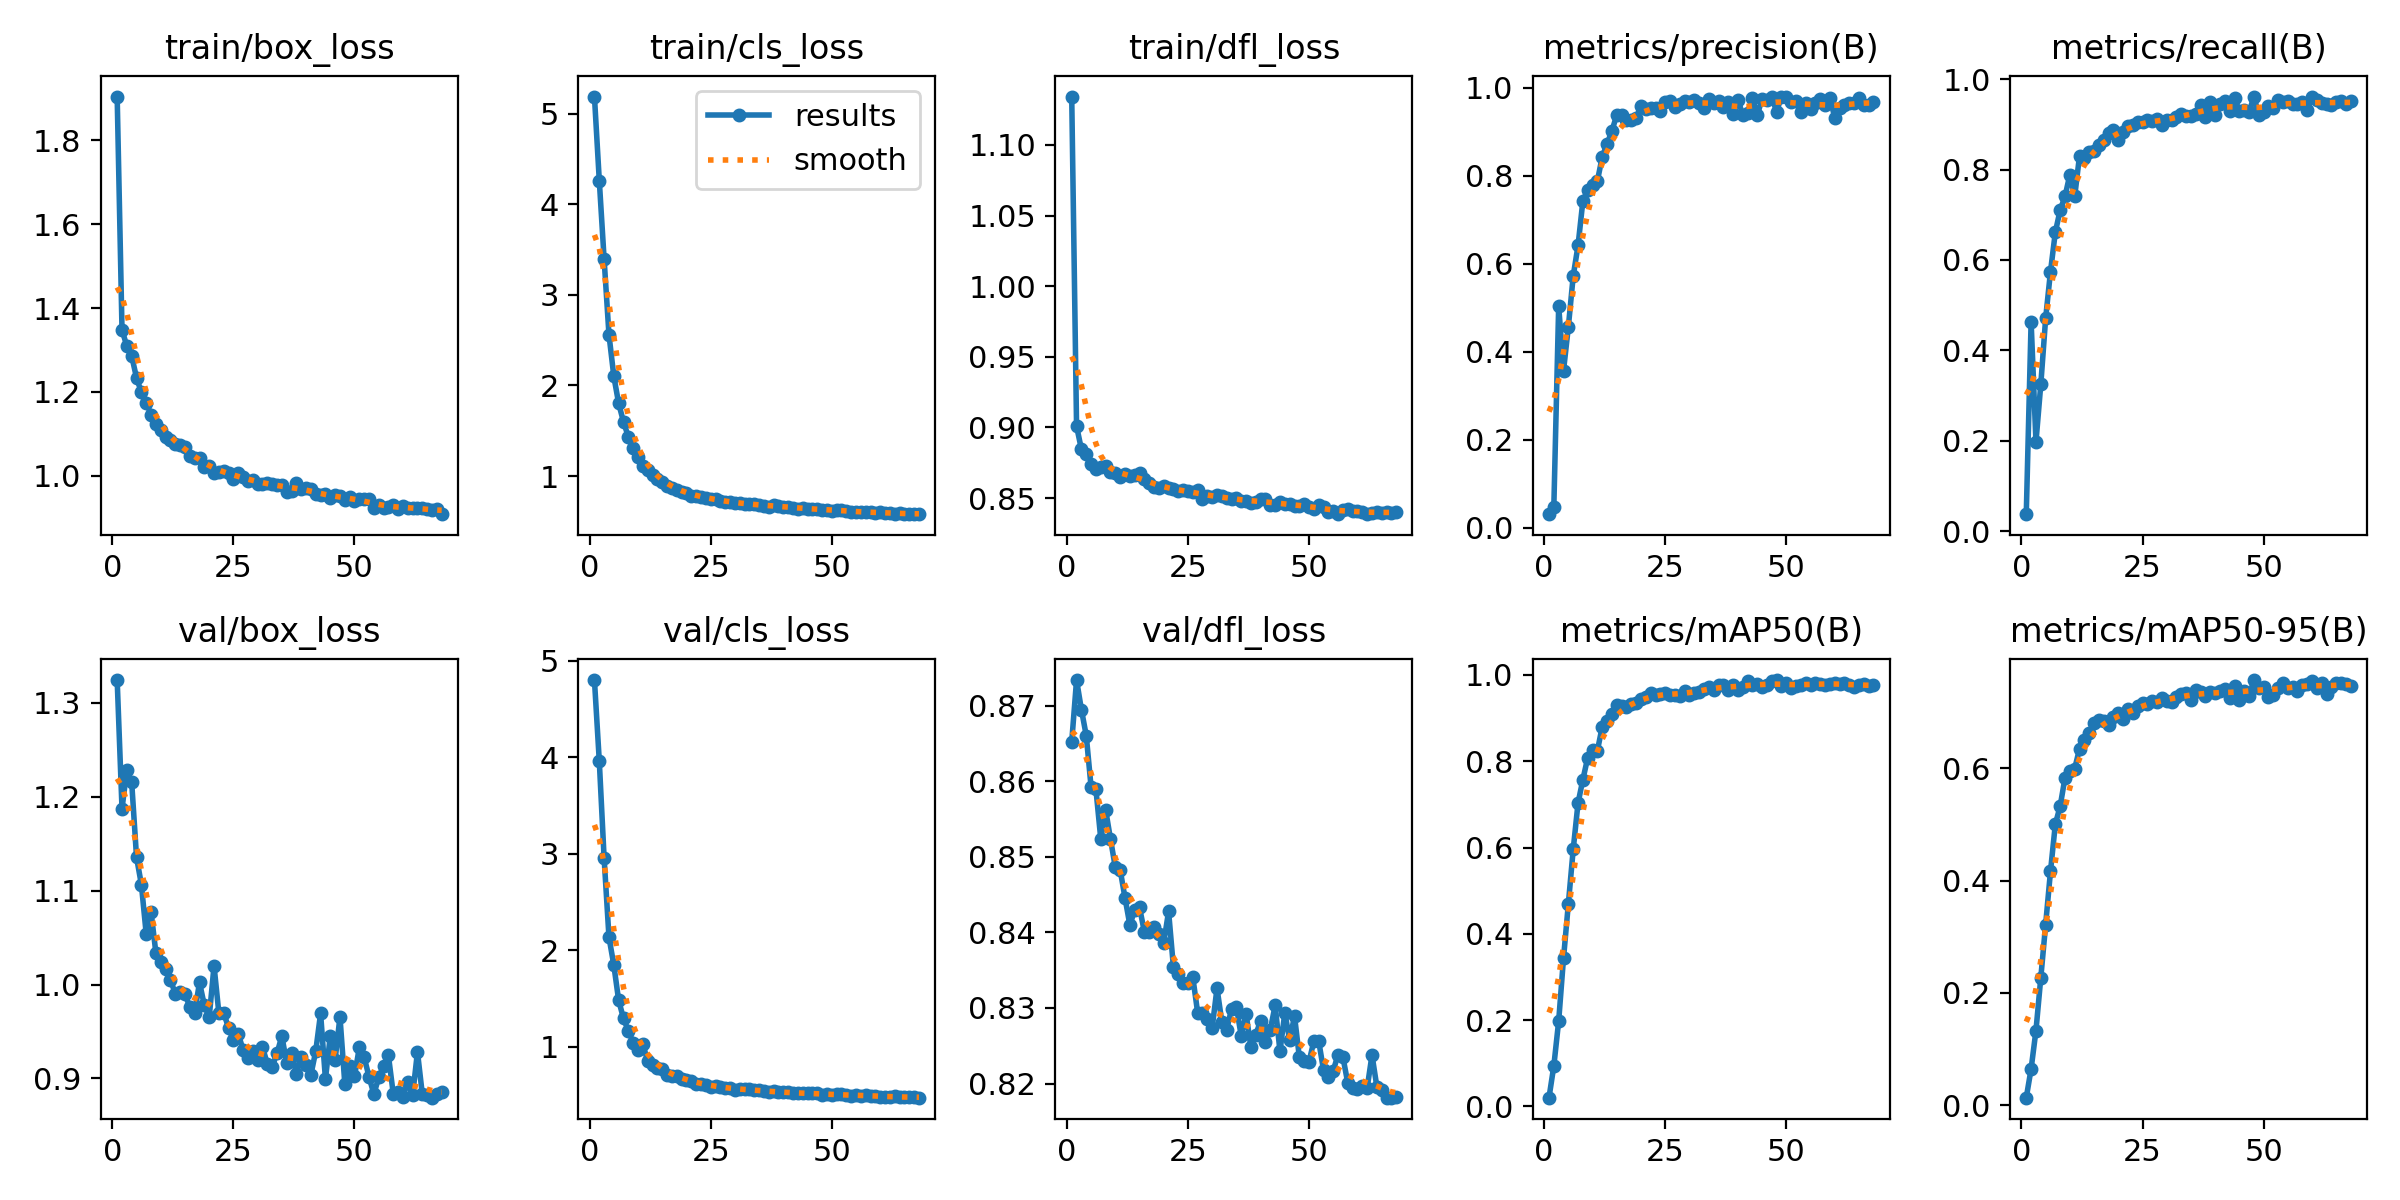

In [32]:
# Visualiser les courbes OCR
results_path_ocr = 'runs/detect/OCR_detection/'
if os.path.exists(results_path_ocr + 'results.png'):
    display(Image(filename=results_path_ocr + 'results.png', width=800))

## 5. Test et Inférence

In [35]:
# Charger les meilleurs modèles entraînés
best_lp_model = YOLO('runs/detect/LP_detection3/weights/best.pt')
best_ocr_model = YOLO('runs/detect/OCR_detection/weights/best.pt')
print("✅ Modèles entraînés chargés !")

✅ Modèles entraînés chargés !


In [44]:
# Tester sur une image du dossier sample
test_image = 'sample/00427.jpg'

# Détection de la plaque
results = best_lp_model.predict(
    source=test_image,
    save=True,
    conf=0.5,           # Seuil de confiance
    name='test_LP'
)

print(f"\n🔍 Résultats pour {test_image}:")
for r in results:
    print(f"   - {len(r.boxes)} plaque(s) détectée(s)")

Results saved to /mnt/c/DEV/jedha/fullstack_wsl/PROJETS/PROJET_FINAL/YOLO8-n/UC3M-LP/runs/detect/test_LP2

🔍 Résultats pour sample/00427.jpg:
   - 1 plaque(s) détectée(s)


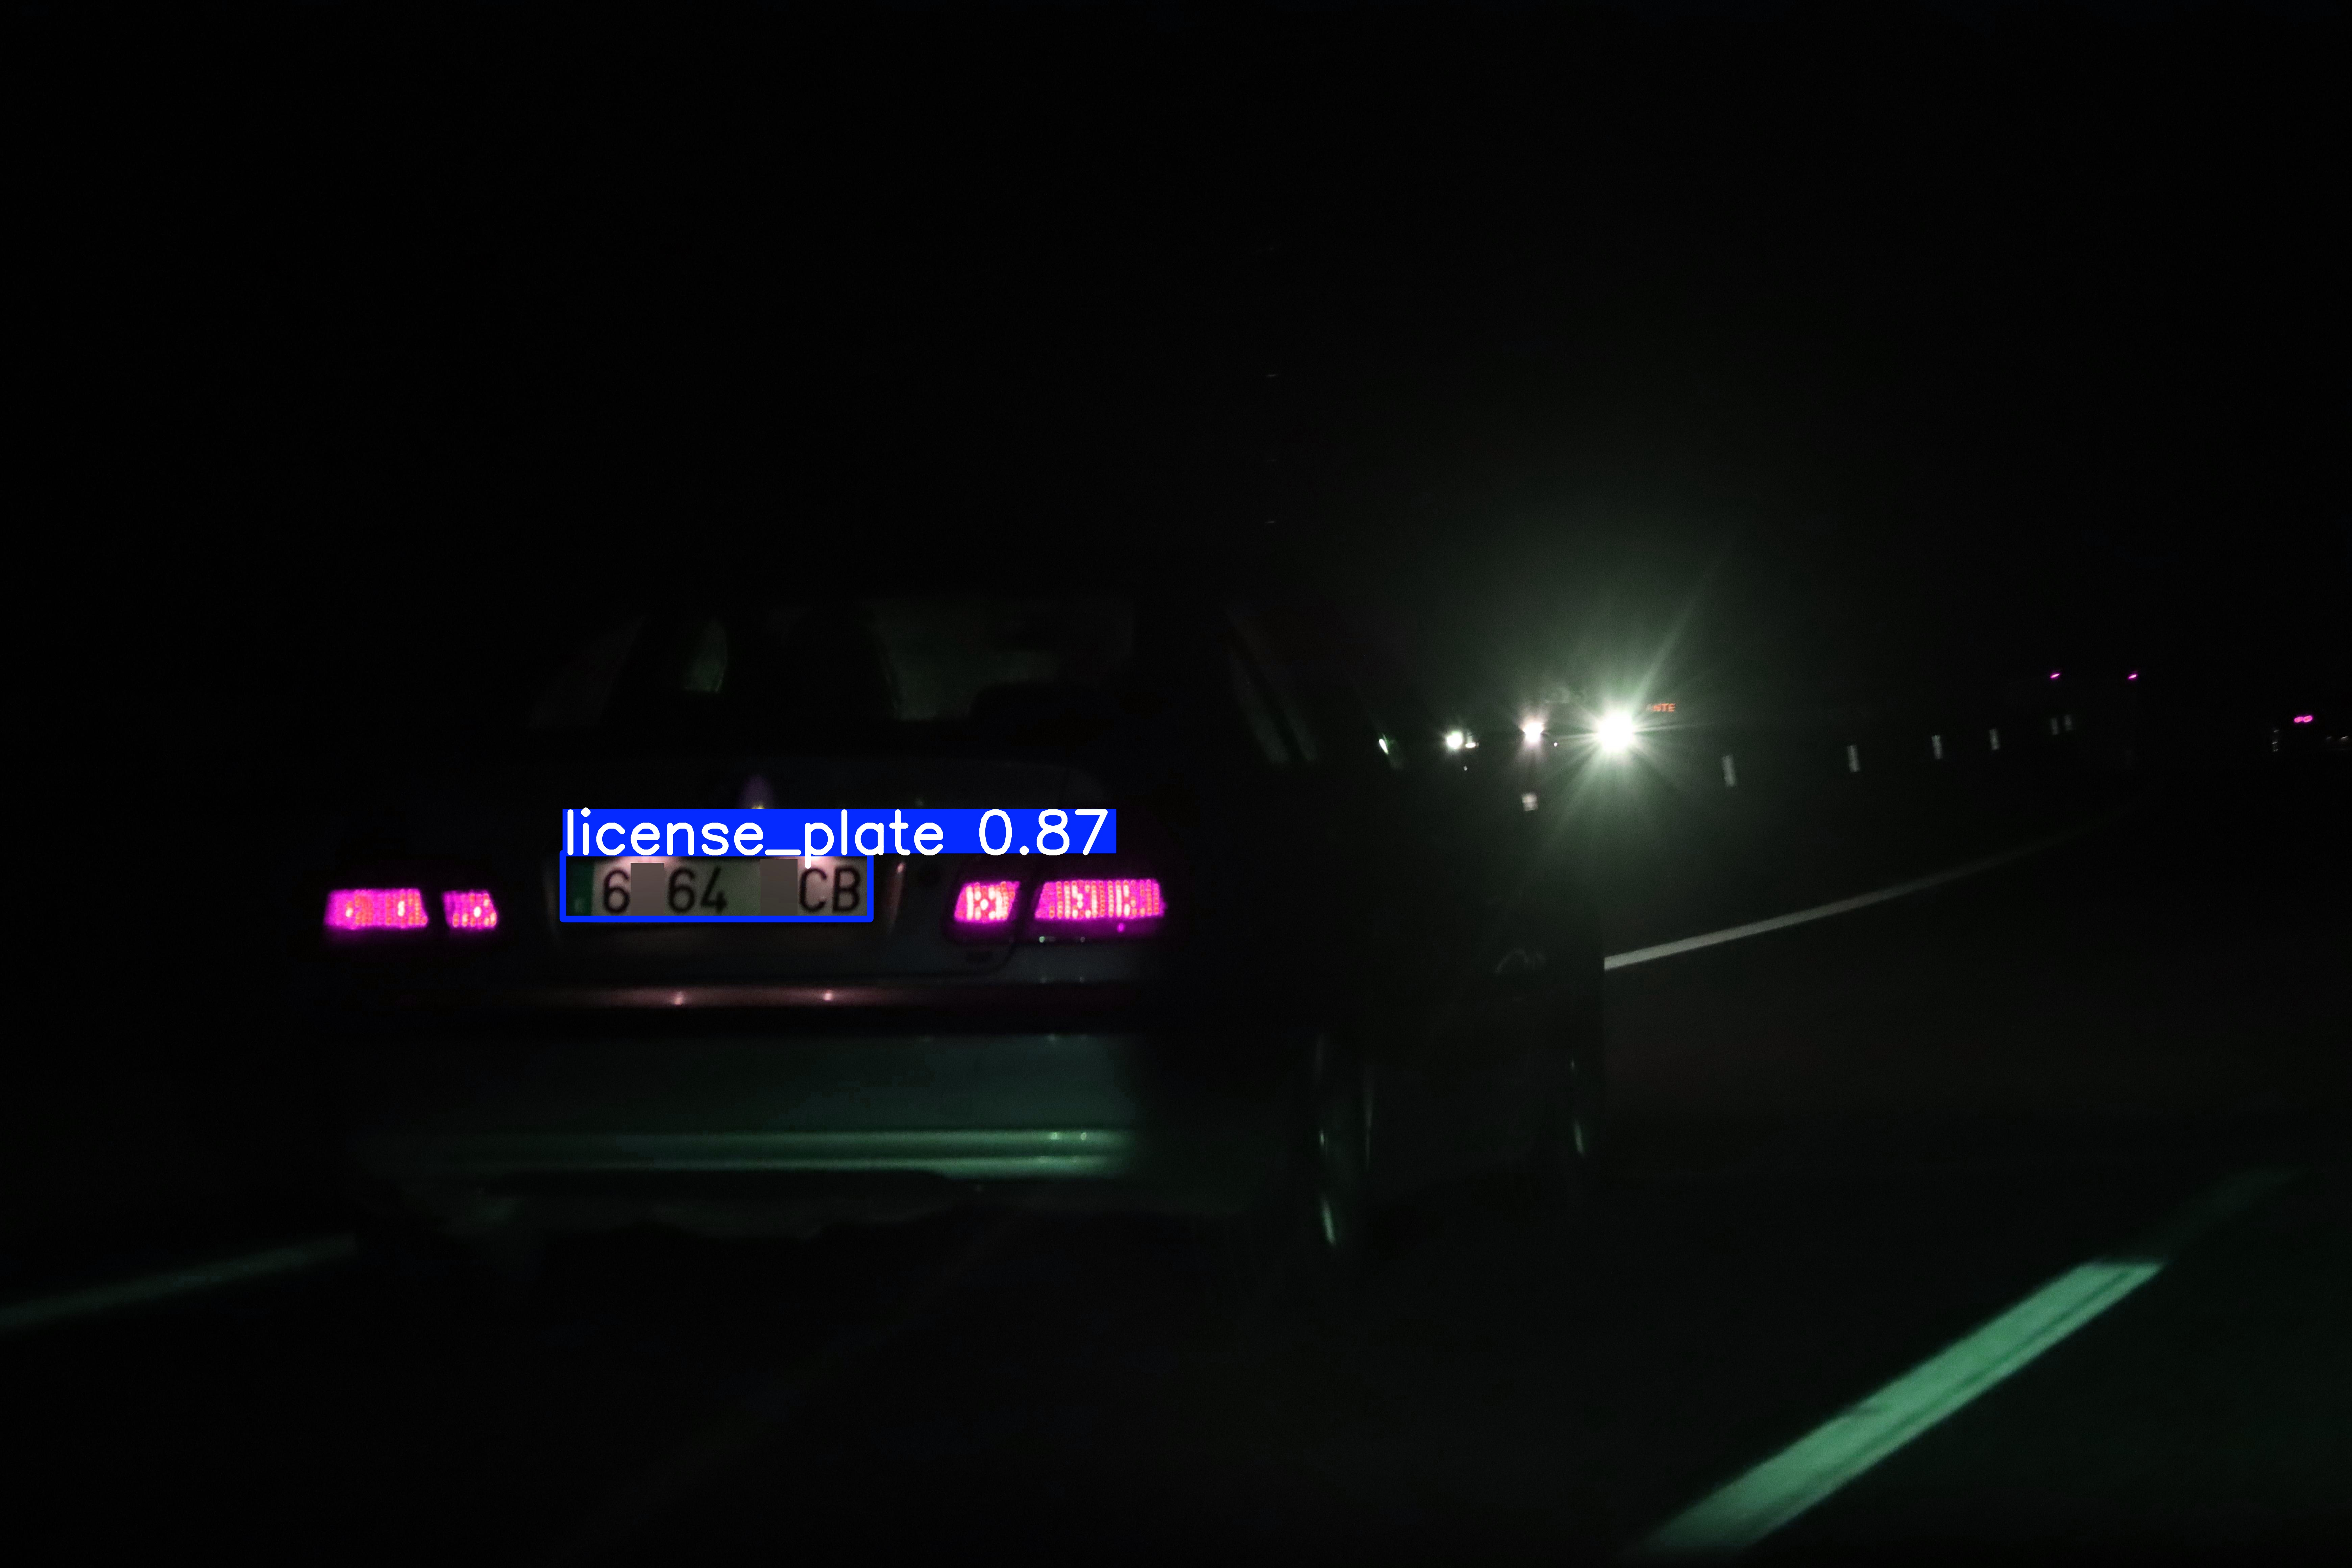

In [46]:
# Afficher l'image avec détection
import glob

# Trouver l'image de sortie
output_images = glob.glob('runs/detect/test_LP2/*.jpg')
if output_images:
    display(Image(filename=output_images[0], width=600))

## 6. Pipeline Complet : Détection + OCR

In [38]:
import cv2
import numpy as np

def detect_and_read_plate(image_path, lp_model, ocr_model, conf_lp=0.5, conf_ocr=0.3):
    """
    Pipeline complet : détecte la plaque puis lit les caractères.
    
    Args:
        image_path: Chemin vers l'image
        lp_model: Modèle de détection de plaque
        ocr_model: Modèle OCR
        conf_lp: Seuil de confiance pour la détection de plaque
        conf_ocr: Seuil de confiance pour l'OCR
    
    Returns:
        Liste des plaques détectées avec leurs caractères
    """
    # Charger l'image
    img = cv2.imread(image_path)
    
    # Étape 1 : Détecter les plaques
    lp_results = lp_model.predict(img, conf=conf_lp, verbose=False)
    
    plates_found = []
    
    for result in lp_results:
        for box in result.boxes:
            # Extraire les coordonnées de la plaque
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            
            # Cropper la plaque
            plate_img = img[y1:y2, x1:x2]
            
            # Étape 2 : OCR sur la plaque
            ocr_results = ocr_model.predict(plate_img, conf=conf_ocr, verbose=False)
            
            # Extraire les caractères et les trier par position x
            chars = []
            for ocr_result in ocr_results:
                for ocr_box in ocr_result.boxes:
                    char_x = ocr_box.xyxy[0][0].item()
                    char_class = int(ocr_box.cls[0].item())
                    char_name = ocr_model.names[char_class]
                    chars.append((char_x, char_name))
            
            # Trier par position x (gauche à droite)
            chars.sort(key=lambda x: x[0])
            plate_text = ''.join([c[1] for c in chars])
            
            plates_found.append({
                'bbox': (x1, y1, x2, y2),
                'text': plate_text,
                'confidence': box.conf[0].item()
            })
    
    return plates_found

In [39]:
# Tester le pipeline complet
test_image = 'sample/00026.jpg'

plates = detect_and_read_plate(
    test_image,
    best_lp_model,
    best_ocr_model
)

print(f"🚗 Résultats pour {test_image}:")
for i, plate in enumerate(plates):
    print(f"\n   Plaque #{i+1}:")
    print(f"   - Texte détecté : {plate['text']}")
    print(f"   - Confiance : {plate['confidence']:.2%}")
    print(f"   - Position : {plate['bbox']}")

🚗 Résultats pour sample/00026.jpg:

   Plaque #1:
   - Texte détecté : 240JV
   - Confiance : 90.82%
   - Position : (1793, 2151, 2629, 2366)

   Plaque #2:
   - Texte détecté : 496TM
   - Confiance : 81.70%
   - Position : (3774, 1099, 4073, 1183)


In [40]:
# Visualiser avec les annotations
import matplotlib.pyplot as plt

def visualize_detection(image_path, plates):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    for plate in plates:
        x1, y1, x2, y2 = plate['bbox']
        # Dessiner le rectangle
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
        # Ajouter le texte
        cv2.putText(img, plate['text'], (x1, y1-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Détection de plaque d\'immatriculation')
    plt.show()

visualize_detection(test_image, plates)

<Figure size 1200x800 with 1 Axes>

## 7. Export du Modèle

In [41]:
# Exporter en ONNX pour déploiement
best_lp_model.export(format='onnx')
print("✅ Modèle LP exporté en ONNX")

Ultralytics 8.4.12 🚀 Python-3.12.3 torch-2.9.1+cu128 CPU (AMD Ryzen 7 7735HS with Radeon Graphics)

PyTorch: starting from 'runs/detect/LP_detection3/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 5, 2100) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/17.5 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.2/17.5 MB 5.4 MB/s eta 0:00:04
   ━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.9/17.5 MB 12.6 MB/s eta 0:00:02
   ━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/17.5 MB 21.1 MB/s eta 0:00:01
   ━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/17.5 MB 27.2 MB/s eta 0:00:01
   ━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/17.5 MB 26.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/17.5 MB 29.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━ 7.7/17.5 MB 31.9 MB/s eta 0:00:01

/home/mmo/venvs/datascience/lib/python3.12/site-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.83...
ONNX: export success ✅ 23.2s, saved as 'runs/detect/LP_detection3/weights/best.onnx' (11.6 MB)

Export complete (24.5s)
Results saved to /mnt/c/DEV/jedha/fullstack_wsl/PROJETS/PROJET_FINAL/YOLO8-n/UC3M-LP/runs/detect/LP_detection3/weights
Predict:         yolo predict task=detect model=runs/detect/LP_detection3/weights/best.onnx imgsz=320 
Validate:        yolo val task=detect model=runs/detect/LP_detection3/weights/best.onnx imgsz=320 data=cfg/UC3M-LP-lp.yaml  
Visualize:       https://netron.app
✅ Modèle LP exporté en ONNX


In [42]:
# Autres formats d'export disponibles :
# - 'torchscript' : pour PyTorch
# - 'onnx' : format universel
# - 'openvino' : pour Intel
# - 'tflite' : pour mobile (TensorFlow Lite)
# - 'coreml' : pour iOS

# Exemple pour TensorFlow Lite (mobile)
# best_lp_model.export(format='tflite')

## 8. Résumé des Fichiers Générés

Après l'entraînement, vous trouverez :

```
runs/detect/
├── LP_detection/
│   ├── weights/
│   │   ├── best.pt      # Meilleur modèle
│   │   └── last.pt      # Dernier checkpoint
│   ├── results.png      # Courbes d'entraînement
│   └── ...
└── OCR_detection/
    ├── weights/
    │   ├── best.pt
    │   └── last.pt
    └── ...
```